<a href="https://colab.research.google.com/github/MarilynMaika/NLP_REPO/blob/main/Hate_Speech_Text_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

from wordcloud import WordCloud
from collections import Counter

## Data Loading
- The dataset was loaded as a single raw column to prevent pandas from incorrectly parsing the inconsistent and noisy CSV structure.
-  The rows were then manually split using the semicolon delimiter to accurately extract the relevant fields, especially the tweet text.
- Finally, only the tweet column was retained and cleaned to ensure a structured and reliable text dataset for NLP preprocessing as shown below.


In [ ]:
# Load entire row as one string
data = pd.read_csv(
    "/content/OmbuiHSRaw (1).csv",
    header=None,
    names=['raw'],
    encoding='utf-8',
    on_bad_lines='skip'
)

# Remove the first row containing the word 'tweet'
data = data[data['raw'] != 'tweet']

# Split into columns
split_cols = data['raw'].str.split(';', n=4, expand=True)

# Assign column names
split_cols.columns = ['empty', 'date', 'label1', 'label2', 'tweet']

# Keep only tweet text and make an explicit copy to avoid SettingWithCopyWarning
data = split_cols[['tweet']].copy()

# Remove quotation marks
data['tweet'] = data['tweet'].str.replace('"', '', regex=False)

data.head()

,tweet
1,That #ShangweVedio should be replaced. Where d...
2,they wrote letters to iebc their bloggers tren...
3,Akombe was a nasa mole Jubilee never wanted ...
4,@paulinenjoroge @OleItumbi @JubileePartyK @Tea...
5,#akombemustgo;;;#akombemustgo;9123662401606778...


## Data Cleaning
For data cleaning  involved Removing HTML Tags & Special Characters and  Handling Whitespace & Extra Spaces. The resulting output was a clean dataset with


In [ ]:
def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove twitter mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtag symbol but keep the word
    text = re.sub(r'#', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
data['clean_text'] = data['tweet'].apply(clean_text)


In [ ]:
data.head()

,tweet,clean_text
1,That #ShangweVedio should be replaced. Where d...,that shangwevedio should be replaced where did...
2,they wrote letters to iebc their bloggers tren...,they wrote letters to iebc their bloggers tren...
3,Akombe was a nasa mole Jubilee never wanted ...,akombe was a nasa mole jubilee never wanted hi...
4,@paulinenjoroge @OleItumbi @JubileePartyK @Tea...,akuna kulala akombemustgo pic twitter com wfyu...
5,#akombemustgo;;;#akombemustgo;9123662401606778...,akombemustgo akombemustgo


### Drop Duplicates

In [ ]:
data.drop_duplicates(subset='clean_text', inplace=True)



In [ ]:
data.head()

,tweet,clean_text
1,That #ShangweVedio should be replaced. Where d...,that shangwevedio should be replaced where did...
2,they wrote letters to iebc their bloggers tren...,they wrote letters to iebc their bloggers tren...
3,Akombe was a nasa mole Jubilee never wanted ...,akombe was a nasa mole jubilee never wanted hi...
4,@paulinenjoroge @OleItumbi @JubileePartyK @Tea...,akuna kulala akombemustgo pic twitter com wfyu...
5,#akombemustgo;;;#akombemustgo;9123662401606778...,akombemustgo akombemustgo


### Handling typos and Mispellings

This section was commented out as it was very computationally expensive

In [ ]:
# from textblob import TextBlob

# def correct_spelling(text):
#     return str(TextBlob(text).correct())


# data['corrected_text'] = data['clean_text'].apply(correct_spelling)

In [ ]:
# from textblob import TextBlob

# # Create independent dataframe copy
# data = data.copy()

# # -----------------------------------
# # SLANG / ABBREVIATION NORMALIZATION
# # -----------------------------------

# slang_dict = {

#     # Common abbreviations
#     "u": "you",
#     "ur": "your",
#     "urs": "yours",
#     "r": "are",
#     "y": "why",
#     "b4": "before",
#     "bc": "because",
#     "bcz": "because",
#     "coz": "because",
#     "cuz": "because",
#     "pls": "please",
#     "plz": "please",
#     "thx": "thanks",
#     "tnx": "thanks",
#     "ty": "thank you",
#     "yw": "you are welcome",
# }

# # -----------------------------------
# # FUNCTION TO NORMALIZE SLANG
# # -----------------------------------

# def normalize_slang(text):

#     words = text.split()

#     normalized_words = [
#         slang_dict[word] if word in slang_dict else word
#         for word in words
#     ]

#     return " ".join(normalized_words)


# # Apply slang normalization
# data['normalized_text'] = (
#     data['clean_text']
#     .fillna("")
#     .apply(normalize_slang)
# )

# # -----------------------------------
# # SPELLING CORRECTION
# # -----------------------------------

# def correct_spelling(text):
#     return str(TextBlob(str(text)).correct())


# # Apply spelling correction
# data['corrected_text'] = (
#     data['normalized_text']
#     .apply(correct_spelling)
# )

# # View results
# data[['clean_text', 'normalized_text', 'corrected_text']].head()

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab', quiet=True)

data['tokens'] = data['clean_text'].apply(word_tokenize)

In [ ]:
data.head()

,tweet,clean_text,tokens
1,That #ShangweVedio should be replaced. Where d...,that shangwevedio should be replaced where did...,"[that, shangwevedio, should, be, replaced, whe..."
2,they wrote letters to iebc their bloggers tren...,they wrote letters to iebc their bloggers tren...,"[they, wrote, letters, to, iebc, their, blogge..."
3,Akombe was a nasa mole Jubilee never wanted ...,akombe was a nasa mole jubilee never wanted hi...,"[akombe, was, a, nasa, mole, jubilee, never, w..."
4,@paulinenjoroge @OleItumbi @JubileePartyK @Tea...,akuna kulala akombemustgo pic twitter com wfyu...,"[akuna, kulala, akombemustgo, pic, twitter, co..."
5,#akombemustgo;;;#akombemustgo;9123662401606778...,akombemustgo akombemustgo,"[akombemustgo, akombemustgo]"


### Stop Word Removal

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

data['tokens'] = data['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

### Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

data['lemmatized'] = data['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [ ]:
data.head()

,tweet,clean_text,tokens,lemmatized
1,That #ShangweVedio should be replaced. Where d...,that shangwevedio should be replaced where did...,"[shangwevedio, replaced, akombemustgo, disappe...","[shangwevedio, replaced, akombemustgo, disappe..."
2,they wrote letters to iebc their bloggers tren...,they wrote letters to iebc their bloggers tren...,"[wrote, letters, iebc, bloggers, trended, akom...","[wrote, letter, iebc, blogger, trended, akombe..."
3,Akombe was a nasa mole Jubilee never wanted ...,akombe was a nasa mole jubilee never wanted hi...,"[akombe, nasa, mole, jubilee, never, wanted, s...","[akombe, nasa, mole, jubilee, never, wanted, s..."
4,@paulinenjoroge @OleItumbi @JubileePartyK @Tea...,akuna kulala akombemustgo pic twitter com wfyu...,"[akuna, kulala, akombemustgo, pic, twitter, co...","[akuna, kulala, akombemustgo, pic, twitter, co..."
5,#akombemustgo;;;#akombemustgo;9123662401606778...,akombemustgo akombemustgo,"[akombemustgo, akombemustgo]","[akombemustgo, akombemustgo]"


### Stemmming

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

data['stemmed'] = data['tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

### Exploratory Data Analysis

1.1 Tweet length distribution

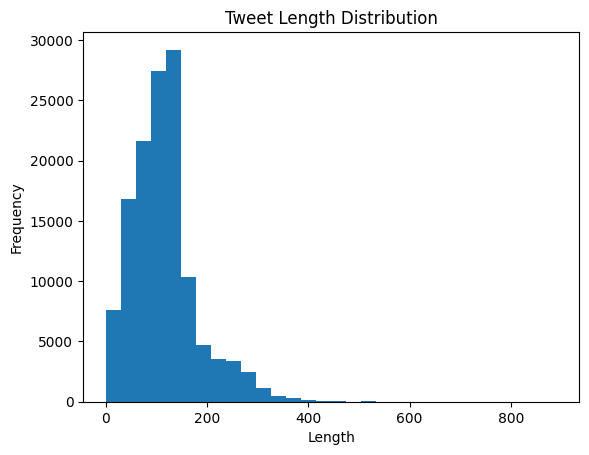

In [ ]:
import matplotlib.pyplot as plt
data["tweet_length"] = data["clean_text"].apply(len)

plt.hist(data["tweet_length"], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

The histogram shows that:
* Most tweets are short, which is typical of Twitter communication.
* The distribution is positively skewed, with only a few very long tweets.
* Longer tweets may contain extended discussions.


## **Word Frequency and Word Cloud**

- Stopwords were removed prior to frequency-based analysis to ensure that the most frequent terms reflected semantic content rather than grammatical structure.

- Without stopword removal, high-frequency words such as “and”, “to”, and “are” dominate the distribution but provide limited analytical value

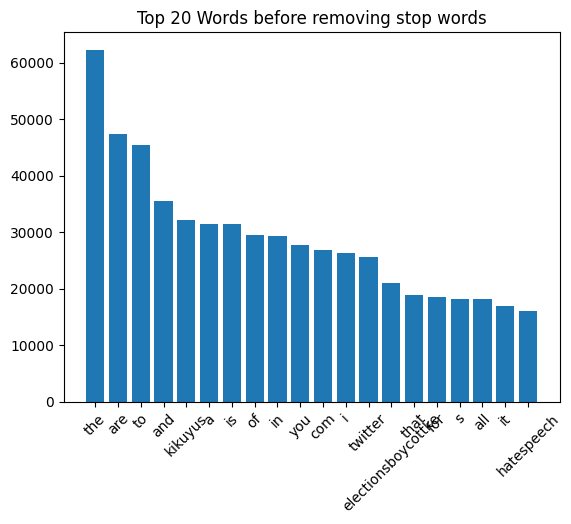

In [ ]:
all_words = " ".join(data["clean_text"]).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words before removing stop words")
plt.show()

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

data["clean_text_no_stopwords"] = data["clean_text"].apply(
    lambda x: " ".join([w for w in x.split() if w not in stop_words])
)



In [ ]:
from collections import Counter

words = " ".join(data["clean_text_no_stopwords"]).split()
word_freq = Counter(words)

common_words = word_freq.most_common(20)
common_words

[('kikuyus', 32232),
 ('com', 26802),
 ('twitter', 25577),
 ('electionsboycottke', 20932),
 ('hatespeech', 16127),
 ('pic', 12282),
 ('hate', 10186),
 ('chase', 9042),
 ('luos', 9041),
 ('hawa', 8395),
 ('kalenjins', 7956),
 ('kenya', 7928),
 ('fagiawote', 7571),
 ('rt', 6849),
 ('people', 6652),
 ('like', 6615),
 ('us', 5546),
 ('democracyorsecession', 5420),
 ('kenyans', 5357),
 ('kenyapoll', 5304)]

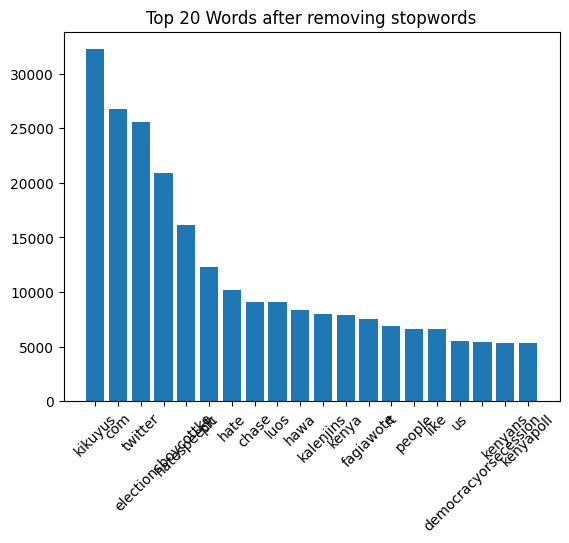

In [ ]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words after removing stopwords")
plt.show()

- The most frequent words before stopword removal include common grammatical words such as “and”, “to”, “are”, which do not carry semantic meaning.

- After stopword removal, the frequent terms shift toward more meaningful content words such as the diffent tribe names which are related to political discussions and user interactions.

- This demonstrates the importance of stopword removal in extracting meaningful patterns from text data.

#### WordCloud

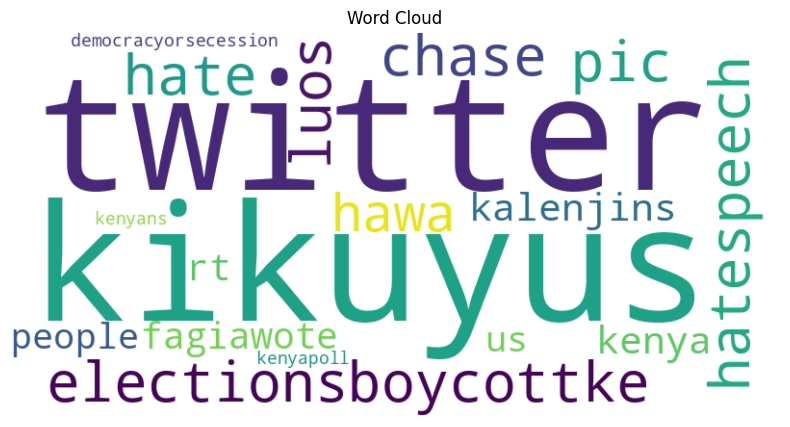

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()



**The Word Cloud shows that:**
- Election-heavy content — terms center on Kenyan elections such as electionsboycottke, voting, and political sentiment.
- Ethnicity is central — Frequent mentions of Kikuyus, Luos, and Kalenjins show ethnic identity drives much of the discourse.
- Divisive, inflammatory language — Terms like "hatespeech" and "democracyorsecession" signal polarized and charged rhetoric.

## Key Takeaway Summary and Findings
### 1. Data Loading and Cleaning

* The dataset had an inconsistent CSV structure.
* Data was loaded as a single raw column and manually split using semicolons.
* 'utf-8' encoding and 'on_bad_lines='skip' were used to handle malformed rows.



### 2. Text Preprocessing

* Removed HTML tags, URLs, mentions, numbers, and special characters.
* Applied tokenization, stopword removal, lemmatization, and stemming.
* Removed extra spaces and duplicate records to improve data quality.



### 3. Computational Constraints

* Spelling correction and slang normalization were identified as useful preprocessing steps.
* These techniques were computationally expensive on the large dataset.
* They were commented out to improve processing efficiency.



### 4. Importance of Stopword Removal

* Initial frequency analysis was dominated by common words like “and” and “to”.
* After stopword removal, meaningful political and hate-related terms became more visible.
* This improved the quality of semantic analysis and visualizations.



### 5. Key Dataset Insights

* Most tweets were short, showing typical Twitter communication patterns.
* The dataset showed a positively skewed tweet-length distribution.
* Common themes included Kenyan elections, ethnic groups, and politically charged language.
* Word frequencies and word clouds revealed the presence of divisive and inflammatory discourse.
